<a href="https://colab.research.google.com/github/Hasan-PU-CSE/Machine-Leaning-Project/blob/main/nlp_code_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-of-nlp-code/nlp dataset/youtube_comments_bn.csv
/kaggle/input/dataset-of-nlp-code/nlp dataset/youtube_comments_bangla.csv
/kaggle/input/dataset-of-nlp-code/nlp dataset/CNBC International_comment_list_20260203.xlsx
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/266.jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/WhatsApp Image 2026-02-03 at 6.19.32 PM (2).jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/WhatsApp Image 2026-02-03 at 6.18.43 PM (1).jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/WhatsApp Image 2026-02-03 at 6.16.58 PM (2).jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/228.jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/130.jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/WhatsApp Image 2026-02-03 at 6.17.03 PM (1).jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image dataset/158.jpeg
/kaggle/input/dataset-of-nlp-code/nlp dataset/image 

In [ ]:
# =========================
# A1) Reproducibility Setup
# =========================
import os, random, json, platform, sys
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

def log_env(out_path="env_info.json"):
    info = {
        "python": sys.version,
        "platform": platform.platform(),
        "seed": SEED,
    }
    try:
        import torch
        info["torch"] = torch.__version__
        info["cuda_available"] = torch.cuda.is_available()
        if torch.cuda.is_available():
            info["cuda_device"] = torch.cuda.get_device_name(0)
    except Exception:
        pass

    try:
        import bertopic, umap, hdbscan, sklearn
        info["bertopic"] = bertopic.__version__
        info["umap"] = umap.__version__
        info["hdbscan"] = hdbscan.__version__
        info["sklearn"] = sklearn.__version__
    except Exception:
        pass

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2, ensure_ascii=False)

log_env("env_info.json")
print(" Reproducibility config set. Saved: env_info.json")

 Reproducibility config set. Saved: env_info.json


In [ ]:
import pandas as pd

# Load both datasets
df1 = pd.read_csv('/kaggle/input/dataset-of-nlp-code/nlp dataset/youtube_comments_bn.csv', encoding='utf-8')
df2 = pd.read_csv('/kaggle/input/dataset-of-nlp-code/nlp dataset/youtube_comments_bangla.csv', encoding='utf-8')

# Check column names (IMPORTANT)
print("DF1 Columns:", df1.columns)
print("DF2 Columns:", df2.columns)

# If columns are same → simple concat
merged_df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicate rows if needed
merged_df = merged_df.drop_duplicates()

# Save new merged dataset
merged_df.to_csv('/kaggle/working/merged_youtube_comments.csv', index=False)

print("Merged dataset shape:", merged_df.shape)
print("Saved successfully!")


DF1 Columns: Index(['comment_id', 'video_url', 'author', 'comment_text'], dtype='str')
DF2 Columns: Index(['comment_id', 'video_url', 'author', 'comment_text'], dtype='str')
Merged dataset shape: (12187, 4)
Saved successfully!


In [ ]:
merged_df.head()

,comment_id,video_url,author,comment_text
0,1,https://youtu.be/qUW6T-1YjPY,@mantiger3780,"Most are talking about AI taking job. But now,..."
1,2,https://youtu.be/qUW6T-1YjPY,@FestivalFloatsLights,"Were you needed 100 people, then you'll need ..."
2,3,https://youtu.be/qUW6T-1YjPY,@Dankpuffin,AI needs to replace these bias and annoying ne...
3,4,https://youtu.be/qUW6T-1YjPY,@kevicen,Yes
4,5,https://youtu.be/qUW6T-1YjPY,@SpittingMage,What if individuals could participate in the A...


In [ ]:
import pandas as pd

# Keep only comment_text
df = merged_df[['comment_text']].copy()

# Drop null values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

print(df.shape)
df.head()


(11090, 1)


,comment_text
0,"Most are talking about AI taking job. But now,..."
1,"Were you needed 100 people, then you'll need ..."
2,AI needs to replace these bias and annoying ne...
3,Yes
4,What if individuals could participate in the A...


In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib tqdm regex
!pip -q install sentence-transformers
!pip -q install bertopic umap-learn hdbscan
!pip -q install gensim


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd

df = merged_df[['comment_text']].copy()
df = df.dropna()
df = df.drop_duplicates()
df.reset_index(drop=True, inplace=True)

print(df.shape)
df.head()

(11090, 1)


,comment_text
0,"Most are talking about AI taking job. But now,..."
1,"Were you needed 100 people, then you'll need ..."
2,AI needs to replace these bias and annoying ne...
3,Yes
4,What if individuals could participate in the A...


In [ ]:
def clean_text(text):
    # Example logic: lowercase and strip whitespace
    text = str(text).lower().strip()
    return text

In [ ]:
df['clean_text'] = df['comment_text'].apply(clean_text)

In [ ]:
df['char_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df.describe()

,char_length,word_count
count,11090.000000,11090.000000
mean,155.033634,27.352390
std,282.613262,47.425113
min,1.000000,1.000000
25%,41.000000,8.000000
50%,86.000000,15.000000
75%,174.000000,31.000000
max,9775.000000,1744.000000


In [ ]:
import re
def detect_language(text):
    if re.search(r'[\u0980-\u09FF]', text) and re.search(r'[a-zA-Z]', text):
        return 'Mixed'
    elif re.search(r'[\u0980-\u09FF]', text):
        return 'Bangla'
    else:
        return 'English'

df['language'] = df['clean_text'].apply(detect_language)

df['language'].value_counts()


language
English    9585
Bangla     1143
Mixed       362
Name: count, dtype: int64

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)

word_freq.most_common(20)


[('the', 10947),
 ('to', 8230),
 ('and', 6855),
 ('a', 5049),
 ('of', 4879),
 ('is', 4747),
 ('ai', 4130),
 ('will', 3230),
 ('in', 3118),
 ('that', 3016),
 ('it', 2860),
 ('be', 2719),
 ('for', 2675),
 ('are', 2449),
 ('i', 2297),
 ('you', 2235),
 ('this', 2230),
 ('they', 1981),
 ('we', 1950),
 ('people', 1859)]

In [ ]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 9.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


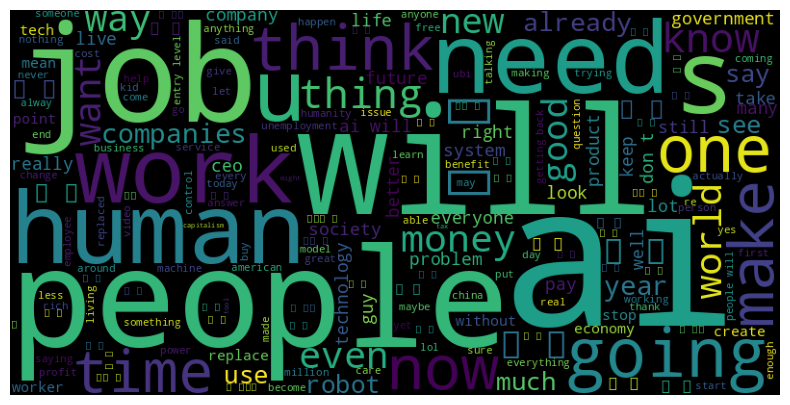

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


In [ ]:
import re
import regex as reg

def clean_text(x: str) -> str:
    x = str(x)

    # Remove URLs
    x = re.sub(r"http\S+|www\.\S+", " ", x)

    # Remove emails
    x = re.sub(r"\S+@\S+", " ", x)

    # Remove @mentions and hashtags (keep word content if you want)
    x = re.sub(r"@\w+", " ", x)
    x = re.sub(r"#", " ", x)

    # Normalize apostrophes
    x = x.replace("’", "'").replace("`", "'")

    # Remove repeated punctuation spam
    x = re.sub(r"[!?.]{3,}", " ", x)

    # Keep: Bangla + English + digits + basic punctuation
    # Bangla Unicode block: \p{Bengali}
    x = reg.sub(r"[^\p{Bengali}A-Za-z0-9\s\.\,\?\!\'\-\(\)\[\]\:\;]", " ", x)

    # Collapse whitespace
    x = re.sub(r"\s+", " ", x).strip()

    return x

df["clean_text"] = df["comment_text"].astype(str).map(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print(df.shape)
df.head()

(10954, 5)


,comment_text,clean_text,char_length,word_count,language
0,"Most are talking about AI taking job. But now,...","Most are talking about AI taking job. But now,...",238,45,English
1,"Were you needed 100 people, then you'll need ...","Were you needed 100 people, then you'll need 1...",82,16,English
2,AI needs to replace these bias and annoying ne...,AI needs to replace these bias and annoying ne...,54,10,English
3,Yes,Yes,3,1,English
4,What if individuals could participate in the A...,What if individuals could participate in the A...,980,127,English


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_tfidf)


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

dtm = vectorizer.fit_transform(df['clean_text'])
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx+1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)



Topic 1:
people ai jobs going don money just need work make

Topic 2:
ai level jobs entry just people need job replace data

Topic 3:
ai like years job people right just jobs lol anderson

Topic 4:
কর আম ai হব আর জন এট আপন আল এই

Topic 5:
ai like just jobs human good job know use work


           char_len      word_len
count  10954.000000  10954.000000
mean     153.817966     27.546650
std      280.735083     47.723375
min        1.000000      1.000000
25%       40.000000      8.000000
50%       85.000000     16.000000
75%      173.000000     31.000000
max     9705.000000   1744.000000


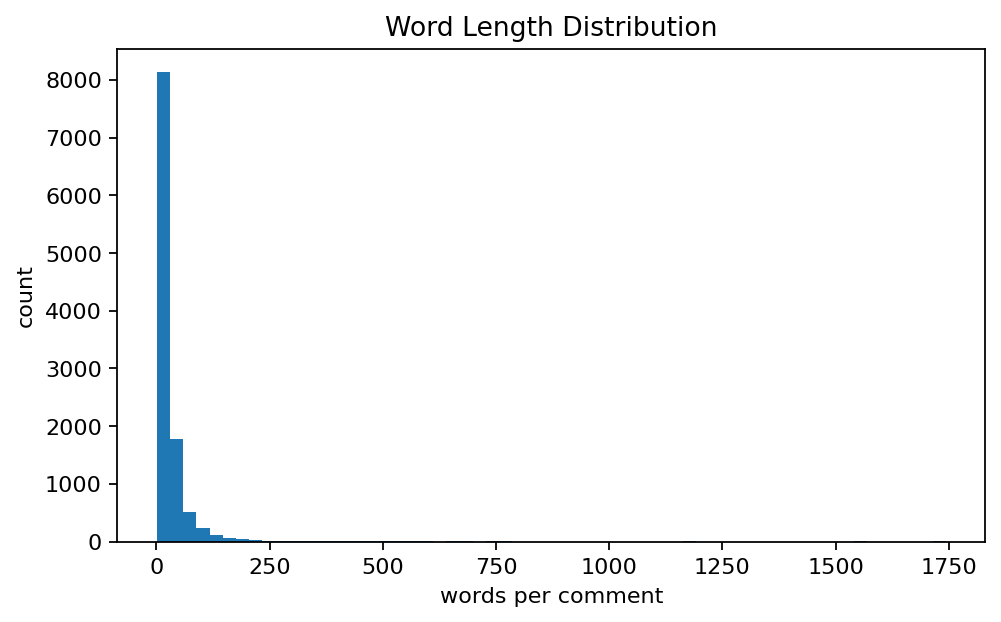

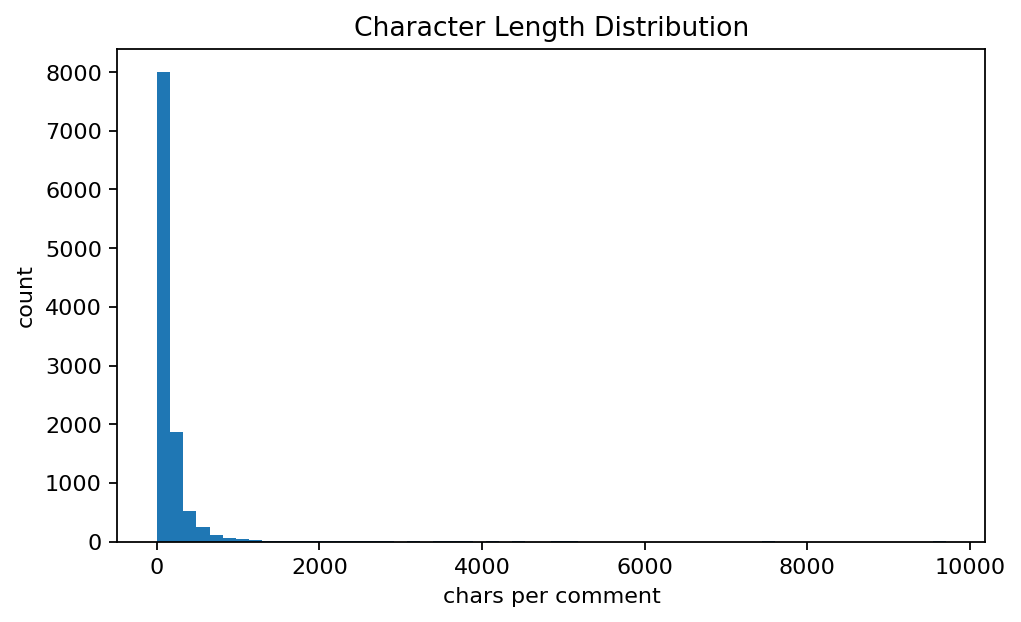

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df["char_len"] = df["clean_text"].str.len()
df["word_len"] = df["clean_text"].str.split().map(len)

print(df[["char_len","word_len"]].describe())

plt.figure(figsize=(7,4), dpi=160)
plt.hist(df["word_len"], bins=60)
plt.title("Word Length Distribution")
plt.xlabel("words per comment")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,4), dpi=160)
plt.hist(df["char_len"], bins=60)
plt.title("Character Length Distribution")
plt.xlabel("chars per comment")
plt.ylabel("count")
plt.show()

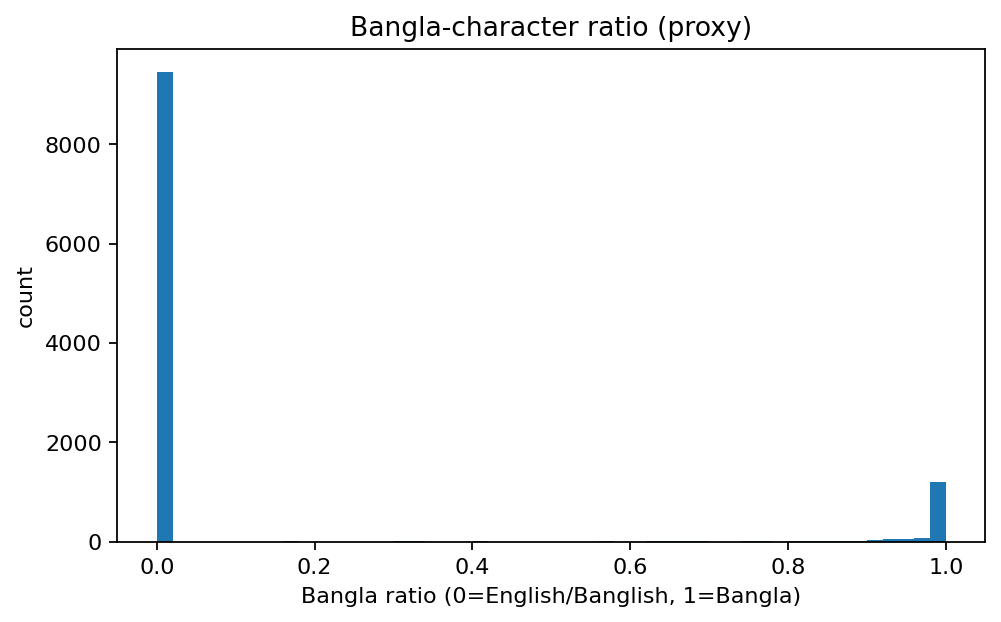

Approx buckets:
Mostly English/Banglish (bn_ratio < 0.2): 9451
Mixed (0.2-0.8): 51
Mostly Bangla (bn_ratio > 0.8): 1452


In [ ]:
import regex as reg

def bangla_ratio(s: str) -> float:
    if not s: return 0.0
    bn = len(reg.findall(r"\p{Bengali}", s))
    total_letters = len(reg.findall(r"[\p{Bengali}A-Za-z]", s))
    return bn / max(total_letters, 1)

df["bn_ratio"] = df["clean_text"].map(bangla_ratio)

plt.figure(figsize=(7,4), dpi=160)
plt.hist(df["bn_ratio"], bins=50)
plt.title("Bangla-character ratio (proxy)")
plt.xlabel("Bangla ratio (0=English/Banglish, 1=Bangla)")
plt.ylabel("count")
plt.show()

print("Approx buckets:")
print("Mostly English/Banglish (bn_ratio < 0.2):", (df["bn_ratio"] < 0.2).sum())
print("Mixed (0.2-0.8):", ((df["bn_ratio"] >= 0.2) & (df["bn_ratio"] <= 0.8)).sum())
print("Mostly Bangla (bn_ratio > 0.8):", (df["bn_ratio"] > 0.8).sum())

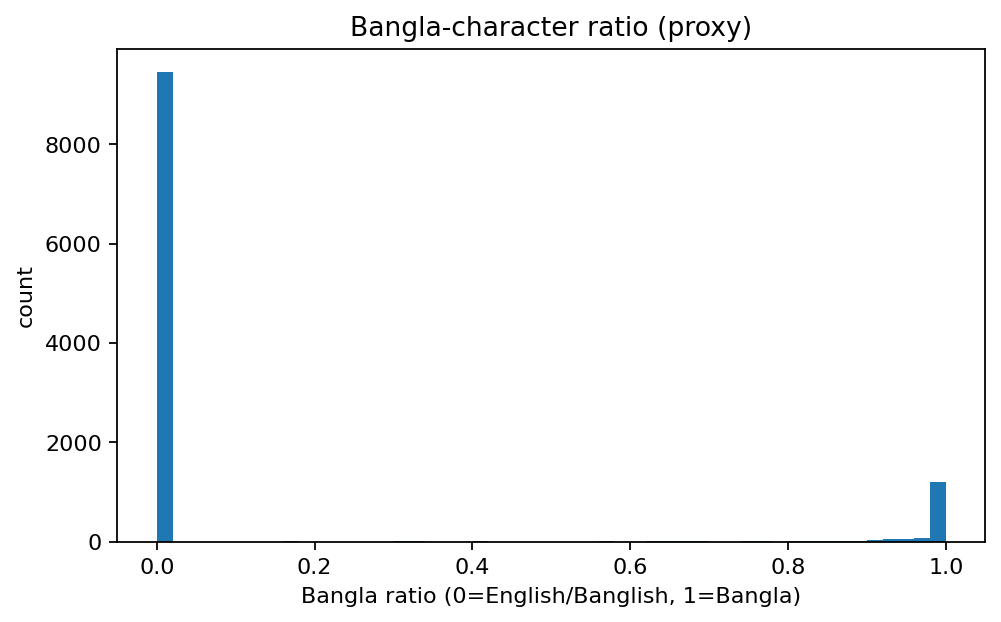

Approx buckets:
Mostly English/Banglish (bn_ratio < 0.2): 9451
Mixed (0.2-0.8): 51
Mostly Bangla (bn_ratio > 0.8): 1452


In [ ]:
import regex as reg

def bangla_ratio(s: str) -> float:
    if not s: return 0.0
    bn = len(reg.findall(r"\p{Bengali}", s))
    total_letters = len(reg.findall(r"[\p{Bengali}A-Za-z]", s))
    return bn / max(total_letters, 1)

df["bn_ratio"] = df["clean_text"].map(bangla_ratio)

plt.figure(figsize=(7,4), dpi=160)
plt.hist(df["bn_ratio"], bins=50)
plt.title("Bangla-character ratio (proxy)")
plt.xlabel("Bangla ratio (0=English/Banglish, 1=Bangla)")
plt.ylabel("count")
plt.show()

print("Approx buckets:")
print("Mostly English/Banglish (bn_ratio < 0.2):", (df["bn_ratio"] < 0.2).sum())
print("Mixed (0.2-0.8):", ((df["bn_ratio"] >= 0.2) & (df["bn_ratio"] <= 0.8)).sum())
print("Mostly Bangla (bn_ratio > 0.8):", (df["bn_ratio"] > 0.8).sum())

In [ ]:
MIN_WORDS = 3
df_f = df[df["word_len"] >= MIN_WORDS].reset_index(drop=True)
print("Before:", df.shape, "After filter:", df_f.shape)

Before: (10954, 8) After filter: (10351, 8)


In [ ]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1


In [ ]:
# remove conflicting versions
!pip -q uninstall -y transformers tokenizers sentence-transformers datasets pyarrow

# install a compatible stack (transformers 4.x)
!pip -q install "transformers==4.57.1" "tokenizers<0.22" -U
!pip -q install "pyarrow>=14.0.1" "datasets>=2.18.0,<3.0.0" -U
!pip -q install "sentence-transformers>=3.0.0" -U

ERROR: Cannot install tokenizers<0.22 and transformers==4.57.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-tunix 0.1.6 requires transformers<=4.57.1, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-tunix 0.1.6 requires transformers<=4.57.1, but you have transformers 5.2.0 which is incompatible.


In [ ]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

EMB_MODEL_NAME = "intfloat/multilingual-e5-base"  # strong multilingual
embedder = SentenceTransformer(EMB_MODEL_NAME)

texts = df_f["clean_text"].tolist()

# E5 models often benefit from prefix like "query: " or "passage: "
# For clustering, use "passage: "
texts_for_emb = [f"passage: {t}" for t in texts]

embeddings = embedder.encode(
    texts_for_emb,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings.shape

/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

(10351, 768)

In [ ]:
from bertopic import BERTopic
from umap import UMAP
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

token_pattern = r"(?u)\b[A-Za-z0-9\u0980-\u09FF][A-Za-z0-9\u0980-\u09FF'\-]{1,}\b"

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    min_df=1,        # important
    max_df=0.95,     # safer for few topics
    token_pattern=token_pattern
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts, embeddings)

2026-02-28 11:46:43,573 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-28 11:47:07,289 - BERTopic - Dimensionality - Completed ✓
2026-02-28 11:47:07,291 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-28 11:47:07,913 - BERTopic - Cluster - Completed ✓
2026-02-28 11:47:07,918 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-28 11:47:08,465 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,90,-1_kardvinkrn_flexwork_stock_flexwork studios,"[kardvinkrn, flexwork, stock, flexwork studios...",[easiest way to expose the deception telling e...
1,0,8517,0_people_we_they_all,"[people, we, they, all, if, jobs, can, or, do,...",[1:51 I am a little bit more worried about the...
2,1,1402,1_ai ai_chatgpt_ai chatgpt_chatgpt ai,"[ai ai, chatgpt, ai chatgpt, chatgpt ai, ai bb...","[bai saddam hossen somporke video den, This vi..."
3,2,254,2_na_and all_er_kore,"[na, and all, er, kore, family all, my family,...",[Eta manuske dhongso korche.emni manusher brai...
4,3,88,3_lamp_lamplighter_lamp lighters_lighters,"[lamp, lamplighter, lamp lighters, lighters, l...",[Thought Anderson was going to inquire how thi...


In [ ]:
# Example: topic 0
topic_model.get_topic(0)[:15]

[('people', np.float64(0.26399082128309015)),
 ('we', np.float64(0.2606363715383989)),
 ('they', np.float64(0.26060168904497544)),
 ('all', np.float64(0.2407220630925547)),
 ('if', np.float64(0.2380394234806728)),
 ('jobs', np.float64(0.2341237984300036)),
 ('can', np.float64(0.22973512675909527)),
 ('or', np.float64(0.22805753065375914)),
 ('do', np.float64(0.2267660186227429)),
 ('about', np.float64(0.22263110839218678))]

In [ ]:
rep_docs = topic_model.get_representative_docs()
# rep_docs is dict: topic_id -> list of docs
list(rep_docs.keys())[:10], rep_docs.get(0, [])[:3]

([-1, 0, 1, 2, 3],
 ["1:51 I am a little bit more worried about the labor impact, simply because it is happening so fast that yes, people will adapt, but they may not adapt fast enough. So, there may be an adjustment period Adapt to what Do these experts have any idea about how the technology they are creating will impact the world we live in today? From what I have read and watched from these experts they have no idea. So, What is he talking about if he does not know where all these advancements are taking us? 8:41 This is an example on how we have to be very careful in how we take control of AI systems Control of AI? Aren't these the same people that say that AI is a self-taught system? And now he mentions feelings? Machines cannot have feelings but they do have mathematical algorithms and they will certainly act upon them. Imagine the algorithm reaching a conclusion that humans are a pest (and we certainly are) and that it is in the best interest to eliminate humans. What will happe

In [ ]:
# 1. Align the DataFrame to the Embeddings
# If your embeddings were generated from the 'top' of the DF:
df_aligned = df.iloc[:len(embeddings)].copy()

# 2. Safety Check
print(f"New DF rows: {len(df_aligned)}")
print(f"Embeddings rows: {embeddings.shape[0]}")



New DF rows: 10351
Embeddings rows: 10351


In [ ]:
import numpy as np
import pandas as pd
import torch
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# --- 1. CONFIGURATION & ALIGNMENT ---
SEED = 42
CLEAN_COL = "clean_text"

# Critical Fix: Align the dataframe to the embeddings size (10351 rows)
if len(df) != len(embeddings):
    print(f"Aligning: DF ({len(df)}) to Embeddings ({len(embeddings)})")
    df_aligned = df.iloc[:len(embeddings)].copy()
else:
    df_aligned = df.copy()

# --- 2. HELPER FUNCTIONS (The "Missing" Pieces) ---
def tokenize_simple(texts):
    return [str(doc).lower().split() for doc in texts]

def coherence_from_topwords(tokenized_docs, top_words, coherence_type):
    if not top_words or not tokenized_docs:
        return np.nan
    dictionary = Dictionary(tokenized_docs)
    corpus = [dictionary.doc2bow(text) for text in tokenized_docs]
    try:
        cm = CoherenceModel(
            topics=top_words,
            texts=tokenized_docs,
            corpus=corpus,
            dictionary=dictionary,
            coherence=coherence_type
        )
        return cm.get_coherence()
    except Exception:
        return np.nan

def topic_diversity(top_words):
    if not top_words or len(top_words) == 0:
        return np.nan
    unique_words = set([word for topic in top_words for word in topic])
    return len(unique_words) / (len(top_words) * len(top_words[0]))

# --- 3. EVALUATION FUNCTION ---
def evaluate_bertopic(topic_model, topics, embeddings, df_local, text_col=CLEAN_COL):
    topics_arr = np.asarray(topics)
    outlier_rate = float((topics_arr == -1).mean())

    mask = topics_arr != -1
    unique = np.unique(topics_arr[mask])

    if len(unique) <= 1:
        sil = ch = dbi = np.nan
    else:
        # Using cosine metric for silhouette as it's standard for embeddings
        sil = float(silhouette_score(embeddings[mask], topics_arr[mask], metric="cosine"))
        ch  = float(calinski_harabasz_score(embeddings[mask], topics_arr[mask]))
        dbi = float(davies_bouldin_score(embeddings[mask], topics_arr[mask]))

    info = topic_model.get_topic_info()
    topic_ids = [t for t in info["Topic"].tolist() if t != -1]

    top_words_lists = []
    for t in topic_ids:
        words = [w for (w, _) in topic_model.get_topic(t)[:10]]
        top_words_lists.append(words)

    texts_list = df_local[text_col].astype(str).fillna("").tolist()
    tokenized = tokenize_simple(texts_list)

    c_v = coherence_from_topwords(tokenized, top_words_lists, "c_v") if top_words_lists else np.nan
    u_m = coherence_from_topwords(tokenized, top_words_lists, "u_mass") if top_words_lists else np.nan
    div = topic_diversity(top_words_lists) if top_words_lists else np.nan

    return {
        "#Topics(excl_outliers)": int(len(topic_ids)),
        "Outlier%": outlier_rate,
        "Coherence_c_v": c_v,
        "Coherence_u_mass": u_m,
        "Diversity": div,
        "Silhouette(emb)": sil,
        "CH(emb)": ch,
        "DBI(emb)": dbi,
    }

# --- 4. ABLATION STUDY LOOP ---
def ablation_bertopic(df_input, embeddings_input, grid, seed=42, text_col=CLEAN_COL):
    rows = []
    texts = df_input[text_col].astype(str).fillna("").tolist()

    for i, params in enumerate(grid):
        print(f"Running iteration {i+1}/{len(grid)}: {params}")

        umap_model = UMAP(
            n_neighbors=params["n_neighbors"],
            min_dist=params["min_dist"],
            n_components=5,
            metric="cosine",
            random_state=seed
        )
        hdbscan_model = HDBSCAN(
            min_cluster_size=params["min_cluster_size"],
            min_samples=params.get("min_samples", 5),
            metric="euclidean",
            prediction_data=True
        )
        vectorizer = CountVectorizer(min_df=3, max_df=0.9, stop_words="english")

        topic_model = BERTopic(
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer,
            calculate_probabilities=False,
            verbose=False
        )

        topics, _ = topic_model.fit_transform(texts, embeddings_input)
        metrics = evaluate_bertopic(topic_model, topics, embeddings_input, df_input, text_col=text_col)

        row = {**params, **metrics}
        rows.append(row)

    return pd.DataFrame(rows)

# --- 5. EXECUTION ---
grid = [
    {"n_neighbors": 5,  "min_dist": 0.0, "min_cluster_size": 15},
    {"n_neighbors": 15, "min_dist": 0.0, "min_cluster_size": 15},
    {"n_neighbors": 50, "min_dist": 0.0, "min_cluster_size": 15},
    {"n_neighbors": 15, "min_dist": 0.1, "min_cluster_size": 15},
    {"n_neighbors": 15, "min_dist": 0.1, "min_cluster_size": 30},
    {"n_neighbors": 15, "min_dist": 0.1, "min_cluster_size": 50},
]

ablation_df = ablation_bertopic(df_aligned, embeddings, grid, seed=SEED)
ablation_df = ablation_df.sort_values(by=["Coherence_c_v", "Diversity"], ascending=False)

# Show results and save
print(ablation_df)
ablation_df.to_csv("ablation_results.csv", index=False)

Running iteration 1/6: {'n_neighbors': 5, 'min_dist': 0.0, 'min_cluster_size': 15}
Running iteration 2/6: {'n_neighbors': 15, 'min_dist': 0.0, 'min_cluster_size': 15}
Running iteration 3/6: {'n_neighbors': 50, 'min_dist': 0.0, 'min_cluster_size': 15}
Running iteration 4/6: {'n_neighbors': 15, 'min_dist': 0.1, 'min_cluster_size': 15}
Running iteration 5/6: {'n_neighbors': 15, 'min_dist': 0.1, 'min_cluster_size': 30}
Running iteration 6/6: {'n_neighbors': 15, 'min_dist': 0.1, 'min_cluster_size': 50}
   n_neighbors  min_dist  min_cluster_size  #Topics(excl_outliers)  Outlier%  \
0            5       0.0                15                     161  0.395324   
1           15       0.0                15                      80  0.385567   
2           50       0.0                15                      56  0.459376   
3           15       0.1                15                       7  0.003381   
4           15       0.1                30                       3  0.005217   
5           15   

In [ ]:
ablation_df.to_csv("ablation_results.csv", index=False)
print(" Saved: ablation_results.csv")

 Saved: ablation_results.csv


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = np.array(topics)

mask = labels != -1
X = embeddings[mask]
y = labels[mask]

print("Non-outlier samples:", X.shape[0], "Clusters:", len(set(y)))

sil = silhouette_score(X, y, metric="cosine")
ch  = calinski_harabasz_score(X, y)
dbi = davies_bouldin_score(X, y)

print(f"Silhouette (cosine): {sil:.4f}")
print(f"Calinski-Harabasz:   {ch:.2f}")
print(f"Davies-Bouldin:      {dbi:.4f}")

Non-outlier samples: 10261 Clusters: 4
Silhouette (cosine): 0.0417
Calinski-Harabasz:   200.12
Davies-Bouldin:      3.8273


In [ ]:
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Tokenize (simple whitespace; already cleaned)
tokenized = [t.split() for t in texts]

dictionary = Dictionary(tokenized)
corpus = [dictionary.doc2bow(toks) for toks in tokenized]

# Extract top words per topic
def get_topic_words(topic_model, top_n=10):
    topics = topic_model.get_topics()
    topic_words = []
    for tid, words in topics.items():
        if tid == -1:
            continue
        topic_words.append([w for w,_ in words[:top_n]])
    return topic_words

topic_words = get_topic_words(topic_model, top_n=10)

# Coherence c_v
cm_cv = CoherenceModel(
    topics=topic_words,
    texts=tokenized,
    dictionary=dictionary,
    coherence="c_v"
)
coh_cv = cm_cv.get_coherence()

# Coherence u_mass (needs corpus)
cm_umass = CoherenceModel(
    topics=topic_words,
    corpus=corpus,
    dictionary=dictionary,
    coherence="u_mass"
)
coh_umass = cm_umass.get_coherence()

# Topic diversity: unique words / total words in topic list
all_words = [w for topic in topic_words for w in topic]
topic_diversity = len(set(all_words)) / max(len(all_words), 1)

print(f"Coherence (c_v):   {coh_cv:.4f}")
print(f"Coherence (u_mass):{coh_umass:.4f}")
print(f"Topic Diversity:   {topic_diversity:.4f}")

Coherence (c_v):   0.4644
Coherence (u_mass):-11.8785
Topic Diversity:   0.9750


In [ ]:
import random

def train_bertopic_with_seed(seed=0):
    um = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=seed)
    hb = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean", cluster_selection_method="eom", prediction_data=True)
    tm = BERTopic(
        umap_model=um,
        hdbscan_model=hb,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=False
    )
    t, _ = tm.fit_transform(texts, embeddings)
    return tm

def top_word_sets(tm, top_n=10):
    tw = get_topic_words(tm, top_n=top_n)
    return [set(x) for x in tw]

def avg_jaccard(listA, listB):
    # compare each topic set in A to best match in B
    scores = []
    for a in listA:
        best = 0
        for b in listB:
            j = len(a & b) / max(len(a | b), 1)
            if j > best: best = j
        scores.append(best)
    return float(np.mean(scores)) if scores else 0.0

seeds = [0, 7, 21]
models = [train_bertopic_with_seed(s) for s in seeds]

sets0 = top_word_sets(models[0], top_n=10)
for i in range(1, len(models)):
    sets_i = top_word_sets(models[i], top_n=10)
    stability = avg_jaccard(sets0, sets_i)
    print(f"Stability vs seed {seeds[i]} (avg best-topic Jaccard): {stability:.4f}")

Stability vs seed 7 (avg best-topic Jaccard): 0.9091
Stability vs seed 21 (avg best-topic Jaccard): 0.9545


In [ ]:
out = df_f.copy()
out["topic_id"] = topics
out["topic_prob"] = [float(np.max(p)) if p is not None else None for p in probs]  # max topic prob

out.to_csv("doc_topics.csv", index=False)
print("Saved: doc_topics.csv")

Saved: doc_topics.csv


In [ ]:
topic_table = topic_model.get_topic_info().copy()

# Add top keywords string
def top_keywords(tid, n=10):
    if tid == -1:
        return ""
    words = topic_model.get_topic(tid)
    return ", ".join([w for w,_ in words[:n]])

topic_table["top_keywords"] = topic_table["Topic"].map(lambda x: top_keywords(x, 12))
topic_table.to_csv("topic_table.csv", index=False)

print("Saved: topic_table.csv")
topic_table.head(15)

Saved: topic_table.csv


,Topic,Count,Name,Representation,Representative_Docs,top_keywords
0,-1,90,-1_kardvinkrn_flexwork_stock_flexwork studios,"[kardvinkrn, flexwork, stock, flexwork studios...",[easiest way to expose the deception telling e...,
1,0,8517,0_people_we_they_all,"[people, we, they, all, if, jobs, can, or, do,...",[1:51 I am a little bit more worried about the...,"people, we, they, all, if, jobs, can, or, do, ..."
2,1,1402,1_ai ai_chatgpt_ai chatgpt_chatgpt ai,"[ai ai, chatgpt, ai chatgpt, chatgpt ai, ai bb...","[bai saddam hossen somporke video den, This vi...","ai ai, chatgpt, ai chatgpt, chatgpt ai, ai bbc..."
3,2,254,2_na_and all_er_kore,"[na, and all, er, kore, family all, my family,...",[Eta manuske dhongso korche.emni manusher brai...,"na, and all, er, kore, family all, my family, ..."
4,3,88,3_lamp_lamplighter_lamp lighters_lighters,"[lamp, lamplighter, lamp lighters, lighters, l...",[Thought Anderson was going to inquire how thi...,"lamp, lamplighter, lamp lighters, lighters, la..."


In [ ]:
# sample 10 docs per topic (excluding -1)
SAMPLE_PER_TOPIC = 10

samples = []
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    sub = out[out["topic_id"] == tid].sample(
        n=min(SAMPLE_PER_TOPIC, (out["topic_id"] == tid).sum()),
        random_state=42
    )
    sub = sub.copy()
    sub["proposed_topic_keywords"] = top_keywords(tid, 12)
    samples.append(sub)

human_df = pd.concat(samples, ignore_index=True)
human_df.to_csv("human_validation_sample.csv", index=False)
print("Saved: human_validation_sample.csv", human_df.shape)

Saved: human_validation_sample.csv (40, 11)


In [ ]:
from sklearn.cluster import KMeans

# Choose K (try 10, 20, 30). You can also use elbow.
K = 20
km = KMeans(n_clusters=K, random_state=42, n_init="auto")
km_labels = km.fit_predict(embeddings)

sil_km = silhouette_score(embeddings, km_labels, metric="cosine")
ch_km  = calinski_harabasz_score(embeddings, km_labels)
dbi_km = davies_bouldin_score(embeddings, km_labels)

print(f"KMeans K={K}")
print(f"Silhouette (cosine): {sil_km:.4f}")
print(f"Calinski-Harabasz:   {ch_km:.2f}")
print(f"Davies-Bouldin:      {dbi_km:.4f}")

KMeans K=20
Silhouette (cosine): 0.0227
Calinski-Harabasz:   146.14
Davies-Bouldin:      4.3788


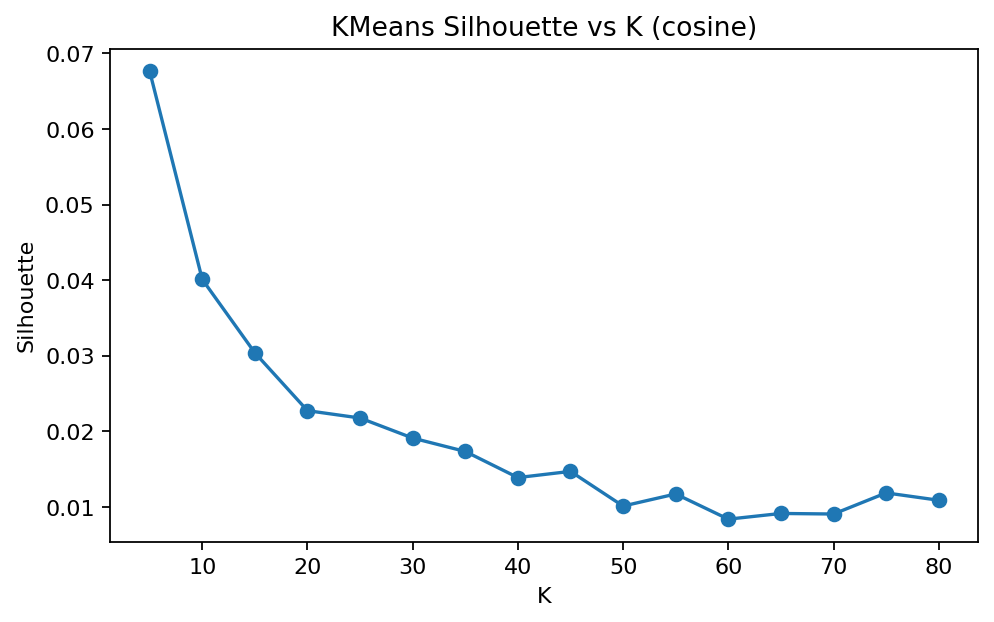

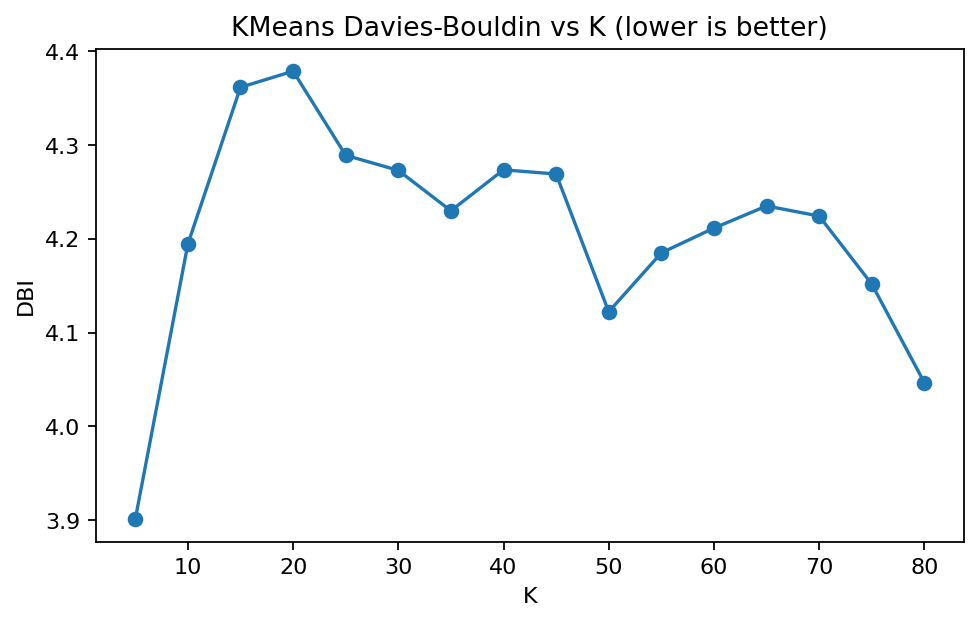

Best K by Silhouette: 5 Sil: 0.0676543116569519
Best K by DBI: 5 DBI: 3.900914563387134


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Ks = list(range(5, 81, 5))
sil_scores, dbi_scores, ch_scores = [], [], []

for K in Ks:
    km = KMeans(n_clusters=K, random_state=42, n_init="auto")
    labels = km.fit_predict(embeddings)

    sil_scores.append(silhouette_score(embeddings, labels, metric="cosine"))
    dbi_scores.append(davies_bouldin_score(embeddings, labels))
    ch_scores.append(calinski_harabasz_score(embeddings, labels))

plt.figure(figsize=(7,4), dpi=160)
plt.plot(Ks, sil_scores, marker="o")
plt.title("KMeans Silhouette vs K (cosine)")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

plt.figure(figsize=(7,4), dpi=160)
plt.plot(Ks, dbi_scores, marker="o")
plt.title("KMeans Davies-Bouldin vs K (lower is better)")
plt.xlabel("K")
plt.ylabel("DBI")
plt.show()

best_k_sil = Ks[int(np.argmax(sil_scores))]
best_k_dbi = Ks[int(np.argmin(dbi_scores))]
print("Best K by Silhouette:", best_k_sil, "Sil:", max(sil_scores))
print("Best K by DBI:", best_k_dbi, "DBI:", min(dbi_scores))

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

km = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=2048,
    n_init="auto"
)
labels = km.fit_predict(embeddings)

print("Silhouette:", silhouette_score(embeddings, labels, metric="cosine"))
print("DBI:", davies_bouldin_score(embeddings, labels))

Silhouette: 0.06572221964597702
DBI: 4.291237692344202


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = np.array(topics)
mask = labels != -1  # exclude outliers

X = embeddings[mask]
y = labels[mask]

print("Non-outlier N:", X.shape[0], "Topics:", len(set(y)))

sil = silhouette_score(X, y, metric="cosine")
ch  = calinski_harabasz_score(X, y)
dbi = davies_bouldin_score(X, y)

print(f"BERTopic/HDBSCAN Silhouette (cosine): {sil:.4f}")
print(f"BERTopic/HDBSCAN Calinski-Harabasz:  {ch:.2f}")
print(f"BERTopic/HDBSCAN Davies-Bouldin:     {dbi:.4f}")

print("Outlier rate:", (labels == -1).mean())

Non-outlier N: 10261 Topics: 4
BERTopic/HDBSCAN Silhouette (cosine): 0.0417
BERTopic/HDBSCAN Calinski-Harabasz:  200.12
BERTopic/HDBSCAN Davies-Bouldin:     3.8273
Outlier rate: 0.008694812095449716


In [ ]:
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

texts_tok = [t.split() for t in texts]
dictionary = Dictionary(texts_tok)
corpus = [dictionary.doc2bow(toks) for toks in texts_tok]

def topic_words(model, topn=10):
    tw = []
    for tid, ws in model.get_topics().items():
        if tid == -1:
            continue
        tw.append([w for w,_ in ws[:topn]])
    return tw

tw = topic_words(topic_model, topn=10)

coh_cv = CoherenceModel(topics=tw, texts=texts_tok, dictionary=dictionary, coherence="c_v").get_coherence()
coh_um = CoherenceModel(topics=tw, corpus=corpus, dictionary=dictionary, coherence="u_mass").get_coherence()

allw = [w for t in tw for w in t]
div = len(set(allw)) / max(len(allw), 1)

print(f"Coherence c_v:   {coh_cv:.4f}")
print(f"Coherence u_mass:{coh_um:.4f}")
print(f"Topic Diversity: {div:.4f}")

Coherence c_v:   0.4644
Coherence u_mass:-11.8785
Topic Diversity: 0.9750


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from umap import UMAP
import hdbscan
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

token_pattern = r"(?u)\b[A-Za-z0-9\u0980-\u09FF][A-Za-z0-9\u0980-\u09FF'\-]{1,}\b"

def run_topic(seed):
    vec = CountVectorizer(ngram_range=(1,2), min_df=1, max_df=0.95, token_pattern=token_pattern)
    um = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=seed)
    hb = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean", cluster_selection_method="eom")
    tm = BERTopic(umap_model=um, hdbscan_model=hb, vectorizer_model=vec, calculate_probabilities=False, verbose=False)
    t, _ = tm.fit_transform(texts, embeddings)
    return np.array(t)

seeds = [0, 7, 21, 42, 99]
runs = [run_topic(s) for s in seeds]

base = runs[0]
for i in range(1, len(runs)):
    a = base
    b = runs[i]
    mask = (a != -1) & (b != -1)
    nmi = normalized_mutual_info_score(a[mask], b[mask])
    ari = adjusted_rand_score(a[mask], b[mask])
    print(f"Seed {seeds[0]} vs {seeds[i]} | NMI={nmi:.4f} ARI={ari:.4f} (on non-outliers={mask.sum()})")

Seed 0 vs 7 | NMI=0.9769 ARI=0.9924 (on non-outliers=10263)
Seed 0 vs 21 | NMI=0.9825 ARI=0.9942 (on non-outliers=10260)
Seed 0 vs 42 | NMI=0.9813 ARI=0.9944 (on non-outliers=10258)
Seed 0 vs 99 | NMI=0.9903 ARI=0.9973 (on non-outliers=10267)


In [ ]:
import regex as reg
import numpy as np

def bn_ratio(s):
    bn = len(reg.findall(r"[\u0980-\u09FF]", s))
    letters = len(reg.findall(r"[\u0980-\u09FFA-Za-z]", s))
    return bn / max(letters, 1)

df_f["bn_ratio"] = df_f["clean_text"].map(bn_ratio)
df_f["topic_id"] = topics

# topic vs language-mix
topic_lang = df_f[df_f["topic_id"] != -1].groupby("topic_id")["bn_ratio"].agg(["count","mean","std"]).sort_values("count", ascending=False)
topic_lang.head(15)

,count,mean,std
topic_id,,,
0,8517,0.000000,0.000000
1,1402,0.960883,0.139512
2,254,0.010496,0.081545
3,88,0.000000,0.000000


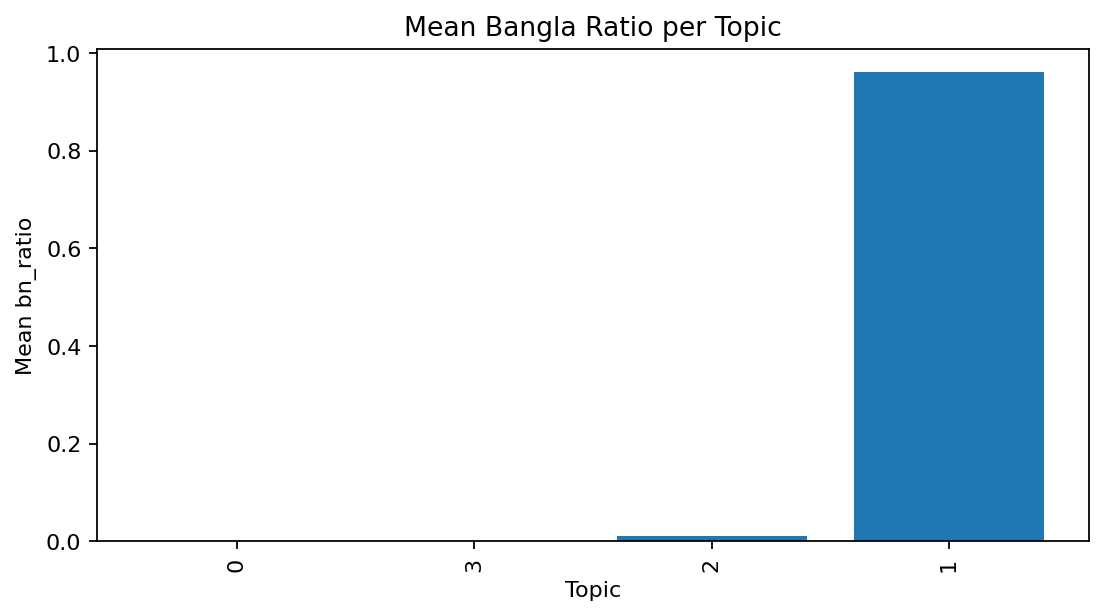

In [ ]:
import matplotlib.pyplot as plt

tmp = topic_lang.reset_index().sort_values("mean")
plt.figure(figsize=(8,4), dpi=160)
plt.bar(tmp["topic_id"].astype(str), tmp["mean"])
plt.xticks(rotation=90)
plt.title("Mean Bangla Ratio per Topic")
plt.xlabel("Topic")
plt.ylabel("Mean bn_ratio")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95
)
X = tfidf.fit_transform(texts)

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_

# show top words per topic
vocab = np.array(tfidf.get_feature_names_out())
for k in range(10):
    top = H[k].argsort()[::-1][:12]
    print(k, vocab[top])

0 ['to' 'we' 'they' 'are' 'and' 'people' 'have' 'need' 'going' 'going to'
 'their' 'that']
1 ['আম' 'হব' 'আল' 'আপন' 'আর' 'এই' 'এর' 'জন' 'সব' 'করত' 'অন' 'হল']
2 ['is' 'this' 'this is' 'guy' 'ai is' 'this guy' 'is the' 'what' 'guy is'
 'why' 'is not' 'that']
3 ['the' 'of' 'in' 'and' 'of the' 'in the' 'that' 'for' 'world' 'on'
 'for the' 'at']
4 ['ai' 'ai is' 'can' 'ai can' 'ai will' 'replace' 'jobs' 'an' 'the ai'
 'an ai' 'of ai' 'with ai']
5 ['you' 'your' 'if you' 'what' 'if' 'you re' 'you are' 'do' 'can' 're'
 'are' 'you can']
6 ['will' 'be' 'will be' 'it will' 'jobs' 'ai will' 'there' 'there will'
 'no' 'by' 'they will' 'to be']
7 ['he' 'his' 'like' 'he is' 'looks' 'he looks' 'was' 'looks like' 'about'
 'he was' 'him' 'company']
8 ['it' 'not' 'but' 'and' 'it is' 'just' 'that' 'was' 'it will' 'it not'
 'like' 'my']
9 ['কর' 'বন' 'বন কর' 'এট' 'উচ' 'কর উচ' 'যবহ' 'যবহ কর' 'এআই' 'এট বন' 'ai বন'
 'ওয়']
